# Estadísticas Descriptivas y Visualización con Pandas y Matplotlib

En este cuaderno aprenderemos a calcular **estadísticas descriptivas** con `pandas` y a crear **gráficos básicos** con `matplotlib`. Trabajaremos con tres tipos de variables:

| Tipo de variable | Descripción | Ejemplo |
|---|---|---|
| **Continua** | Puede tomar cualquier valor en un intervalo | Estatura, peso, temperatura |
| **Discreta** | Toma valores enteros o contables | Número de hijos, cantidad de materias |
| **Categórica** | Representa categorías o grupos | Color favorito, estado civil, nivel educativo |

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración general de los gráficos
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Crear un conjunto de datos de ejemplo

Simulamos una encuesta a 200 estudiantes universitarios con variables de distintos tipos.

In [2]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    # Variables continuas
    "estatura_cm": np.random.normal(loc=168, scale=10, size=n).round(1),
    "peso_kg": np.random.normal(loc=68, scale=12, size=n).round(1),
    "promedio_notas": np.random.uniform(low=2.5, high=5.0, size=n).round(2),

    # Variables discretas
    "num_materias": np.random.poisson(lam=5, size=n),
    "num_hermanos": np.random.choice([0, 1, 2, 3, 4, 5], size=n, p=[0.10, 0.25, 0.30, 0.20, 0.10, 0.05]),
    "horas_estudio_semana": np.random.randint(low=2, high=25, size=n),

    # Variables categóricas
    "genero": np.random.choice(["Femenino", "Masculino", "Otro"], size=n, p=[0.50, 0.45, 0.05]),
    "estrato": np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.15, 0.35, 0.25, 0.15, 0.05]),
    "carrera": np.random.choice(
        ["Ingeniería", "Medicina", "Derecho", "Economía", "Psicología"],
        size=n, p=[0.25, 0.15, 0.20, 0.20, 0.20]
    ),
})

# Convertir categóricas a tipo adecuado
df["genero"] = df["genero"].astype("category")
df["estrato"] = df["estrato"].astype("category")
df["carrera"] = df["carrera"].astype("category")

df.head(10)

,estatura_cm,peso_kg,promedio_notas,num_materias,num_hermanos,horas_estudio_semana,genero,estrato,carrera
0,173.0,72.3,3.54,3,2,17,Masculino,3,Medicina
1,166.6,74.7,3.18,6,2,2,Masculino,3,Ingeniería
2,174.5,81.0,2.64,7,3,14,Masculino,1,Economía
3,183.2,80.6,4.66,8,0,24,Femenino,3,Economía
4,165.7,51.5,4.53,6,2,22,Masculino,3,Medicina
5,165.7,56.7,5.00,3,2,22,Femenino,3,Economía
6,183.8,74.2,4.99,7,2,14,Femenino,6,Medicina
7,175.7,74.2,3.89,5,0,3,Femenino,5,Economía
8,163.3,74.2,4.42,5,2,5,Masculino,4,Ingeniería
9,173.4,114.2,4.86,7,2,7,Otro,3,Psicología


In [3]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   estatura_cm           200 non-null    float64 
 1   peso_kg               200 non-null    float64 
 2   promedio_notas        200 non-null    float64 
 3   num_materias          200 non-null    int64   
 4   num_hermanos          200 non-null    int64   
 5   horas_estudio_semana  200 non-null    int64   
 6   genero                200 non-null    category
 7   estrato               200 non-null    category
 8   carrera               200 non-null    category
dtypes: category(3), float64(3), int64(3)
memory usage: 10.2 KB


---

## 3. Variables Continuas

Las variables continuas pueden tomar **cualquier valor real** dentro de un rango. En nuestro dataset tenemos: `estatura_cm`, `peso_kg` y `promedio_notas`.

### 3.1 Estadísticas descriptivas

In [4]:
vars_continuas = ["estatura_cm", "peso_kg", "promedio_notas"]

# describe() calcula automáticamente las principales estadísticas
df[vars_continuas].describe().round(2)

,estatura_cm,peso_kg,promedio_notas
count,200.00,200.00,200.00
mean,167.59,69.03,3.67
std,9.31,11.85,0.71
min,141.80,29.10,2.54
25%,160.98,60.72,3.03
50%,168.00,68.95,3.64
75%,173.02,76.22,4.21
max,195.20,114.20,5.00


In [5]:
# Estadísticas adicionales: mediana, varianza, asimetría y curtosis
resumen_continuas = pd.DataFrame({
    "Media": df[vars_continuas].mean(),
    "Mediana": df[vars_continuas].median(),
    "Desv. Estándar": df[vars_continuas].std(),
    "Varianza": df[vars_continuas].var(),
    "Asimetría": df[vars_continuas].skew(),
    "Curtosis": df[vars_continuas].kurtosis(),
    "Mínimo": df[vars_continuas].min(),
    "Máximo": df[vars_continuas].max(),
})

resumen_continuas.round(3)

,Media,Mediana,Desv. Estándar,Varianza,Asimetría,Curtosis,Mínimo,Máximo
estatura_cm,167.593,168.00,9.309,86.656,0.134,0.029,141.80,195.2
peso_kg,69.032,68.95,11.845,140.307,0.173,0.819,29.10,114.2
promedio_notas,3.668,3.64,0.710,0.504,0.233,-1.134,2.54,5.0


### 3.2 Visualización de variables continuas

#### Histograma
El histograma muestra la **distribución de frecuencias** de una variable continua, agrupando los valores en intervalos (bins).

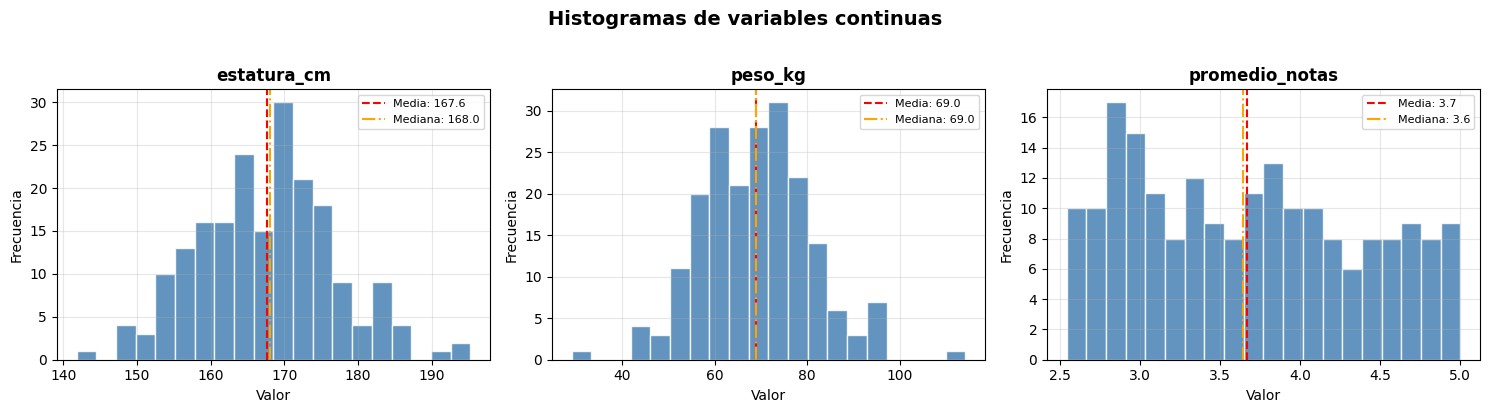

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, vars_continuas):
    ax.hist(df[var], bins=20, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(df[var].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Media: {df[var].mean():.1f}")
    ax.axvline(df[var].median(), color="orange", linestyle="-.", linewidth=1.5, label=f"Mediana: {df[var].median():.1f}")
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

fig.suptitle("Histogramas de variables continuas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Diagrama de caja (Boxplot)
El boxplot resume la distribución mostrando la **mediana**, los **cuartiles** (Q1, Q3) y los **valores atípicos**.

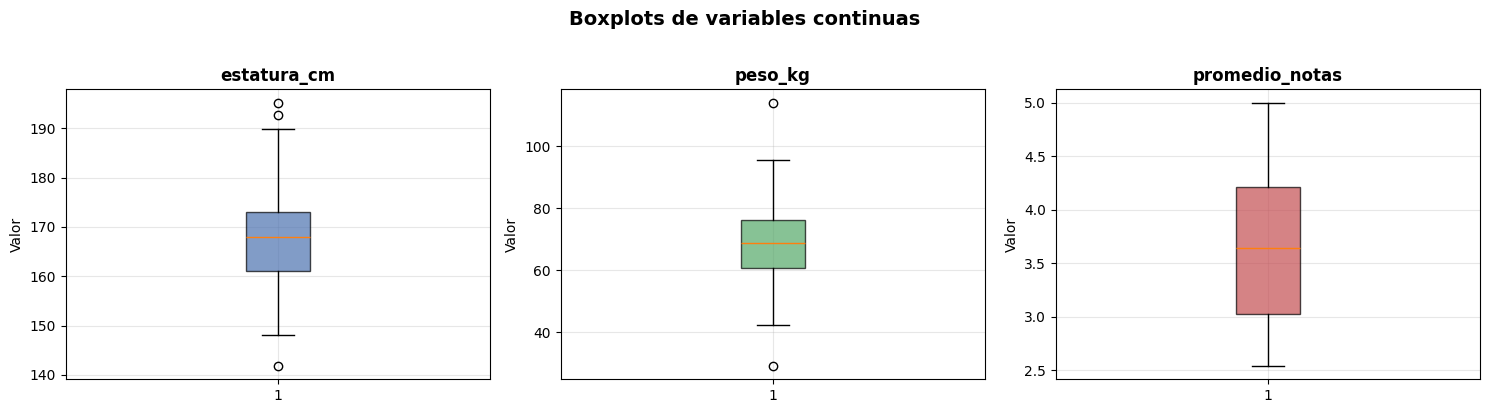

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colores = ["#4C72B0", "#55A868", "#C44E52"]

for ax, var, color in zip(axes, vars_continuas, colores):
    bp = ax.boxplot(df[var], patch_artist=True, vert=True)
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.7)
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_ylabel("Valor")

fig.suptitle("Boxplots de variables continuas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Dispersión (Scatter plot)
El gráfico de dispersión permite explorar la **relación entre dos variables continuas**.

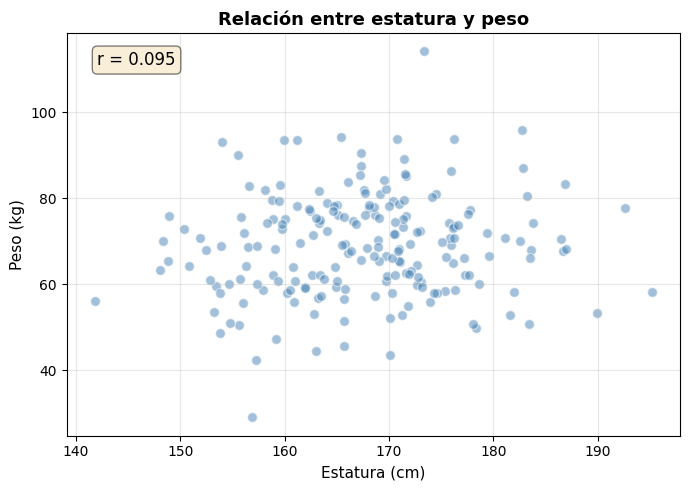

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df["estatura_cm"], df["peso_kg"], alpha=0.5, color="steelblue", edgecolors="white", s=50)
ax.set_xlabel("Estatura (cm)", fontsize=11)
ax.set_ylabel("Peso (kg)", fontsize=11)
ax.set_title("Relación entre estatura y peso", fontsize=13, fontweight="bold")

# Correlación de Pearson
corr = df["estatura_cm"].corr(df["peso_kg"])
ax.annotate(f"r = {corr:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

---

## 4. Variables Discretas

Las variables discretas toman **valores enteros o contables**. En nuestro dataset: `num_materias`, `num_hermanos` y `horas_estudio_semana`.

### 4.1 Estadísticas descriptivas

In [9]:
vars_discretas = ["num_materias", "num_hermanos", "horas_estudio_semana"]

df[vars_discretas].describe().round(2)

,num_materias,num_hermanos,horas_estudio_semana
count,200.00,200.00,200.00
mean,4.98,2.06,13.09
std,2.26,1.28,6.96
min,0.00,0.00,2.00
25%,3.00,1.00,7.00
50%,5.00,2.00,13.50
75%,7.00,3.00,20.00
max,11.00,5.00,24.00


In [10]:
# Moda y tablas de frecuencia para variables discretas
for var in vars_discretas:
    moda = df[var].mode().values[0]
    print(f"--- {var} ---")
    print(f"  Moda: {moda}")
    print(f"  Tabla de frecuencias:")
    print(df[var].value_counts().sort_index().to_string())
    print()

--- num_materias ---
  Moda: 5
  Tabla de frecuencias:
num_materias
0      1
1     10
2     17
3     27
4     32
5     37
6     23
7     24
8     18
9      3
10     7
11     1

--- num_hermanos ---
  Moda: 2
  Tabla de frecuencias:
num_hermanos
0    22
1    48
2    62
3    41
4    19
5     8

--- horas_estudio_semana ---
  Moda: 4
  Tabla de frecuencias:
horas_estudio_semana
2      9
3     10
4     15
5      9
6      5
7      9
8      3
9      9
10    15
11     1
12     5
13    10
14     5
15    14
16    11
17     8
18     6
19     4
20     9
21    12
22    15
23     6
24    10



### 4.2 Visualización de variables discretas

#### Gráfico de barras de frecuencia
Para variables discretas, el gráfico de barras es más adecuado que el histograma, ya que cada valor entero tiene su propia barra.

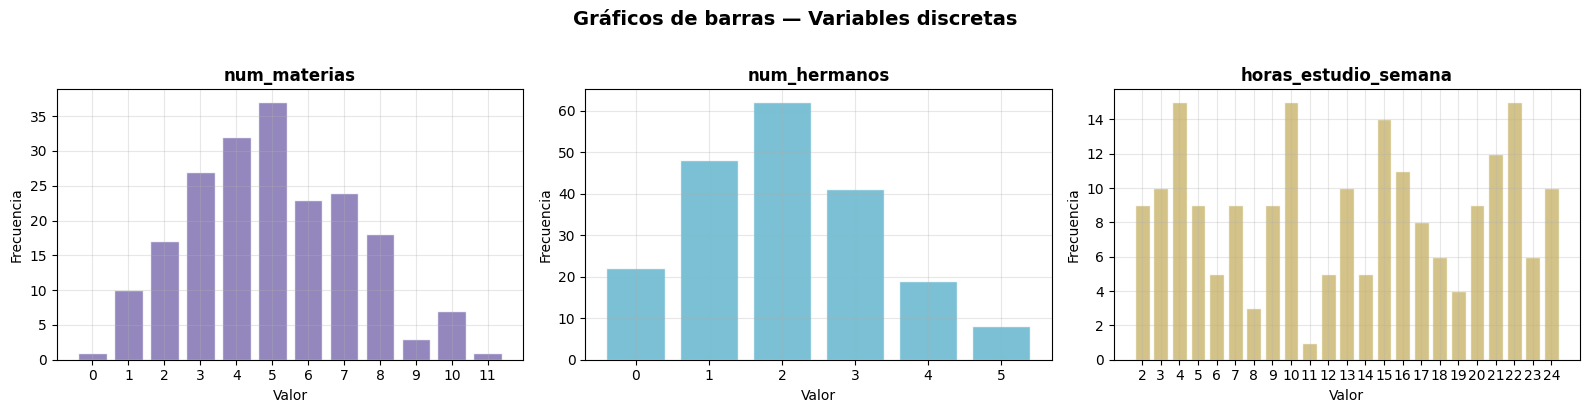

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colores_disc = ["#8172B2", "#64B5CD", "#CCB974"]

for ax, var, color in zip(axes, vars_discretas, colores_disc):
    conteos = df[var].value_counts().sort_index()
    ax.bar(conteos.index.astype(str), conteos.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

fig.suptitle("Gráficos de barras — Variables discretas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Diagrama de tallo (Stem plot)
El stem plot es útil para variables discretas con pocos valores únicos, como `num_hermanos`.

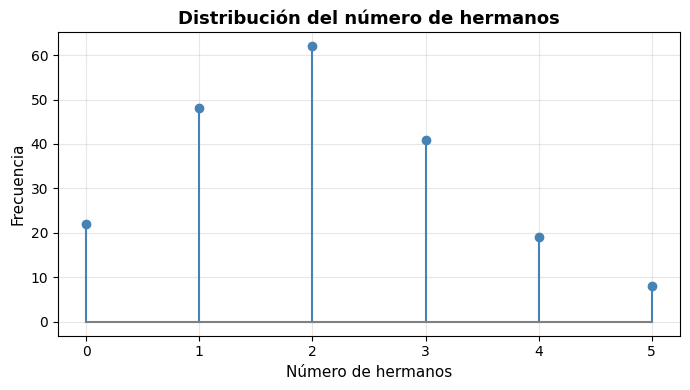

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

conteos_hermanos = df["num_hermanos"].value_counts().sort_index()
ax.stem(conteos_hermanos.index, conteos_hermanos.values, linefmt="steelblue", markerfmt="o", basefmt="gray")
ax.set_xlabel("Número de hermanos", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_title("Distribución del número de hermanos", fontsize=13, fontweight="bold")
ax.set_xticks(conteos_hermanos.index)

plt.tight_layout()
plt.show()

---

## 5. Variables Categóricas

Las variables categóricas representan **grupos o categorías** sin orden numérico inherente (nominales) o con un orden natural (ordinales). En nuestro dataset: `genero`, `estrato` y `carrera`.

### 5.1 Estadísticas descriptivas

Para variables categóricas las medidas relevantes son: **frecuencias absolutas y relativas**, y la **moda**.

In [13]:
vars_categoricas = ["genero", "estrato", "carrera"]

# describe() para categóricas muestra conteo, categorías únicas, moda y frecuencia de la moda
df[vars_categoricas].describe()

,genero,estrato,carrera
count,200,200,200
unique,3,6,5
top,Femenino,3,Ingeniería
freq,110,73,55


In [14]:
# Tablas de frecuencia absoluta y relativa
for var in vars_categoricas:
    freq_abs = df[var].value_counts()
    freq_rel = df[var].value_counts(normalize=True).mul(100).round(1)
    tabla = pd.DataFrame({"Frecuencia": freq_abs, "Porcentaje (%)": freq_rel})
    print(f"\n{'='*40}")
    print(f"  {var.upper()}")
    print(f"{'='*40}")
    print(tabla.to_string())
    print(f"  Moda: {df[var].mode().values[0]}")


  GENERO
           Frecuencia  Porcentaje (%)
genero                               
Femenino          110            55.0
Masculino          79            39.5
Otro               11             5.5
  Moda: Femenino

  ESTRATO
         Frecuencia  Porcentaje (%)
estrato                            
3                73            36.5
4                49            24.5
5                31            15.5
2                26            13.0
6                12             6.0
1                 9             4.5
  Moda: 3

  CARRERA
            Frecuencia  Porcentaje (%)
carrera                               
Ingeniería          55            27.5
Psicología          38            19.0
Derecho             37            18.5
Economía            37            18.5
Medicina            33            16.5
  Moda: Ingeniería


### 5.2 Visualización de variables categóricas

#### Gráfico de barras horizontales

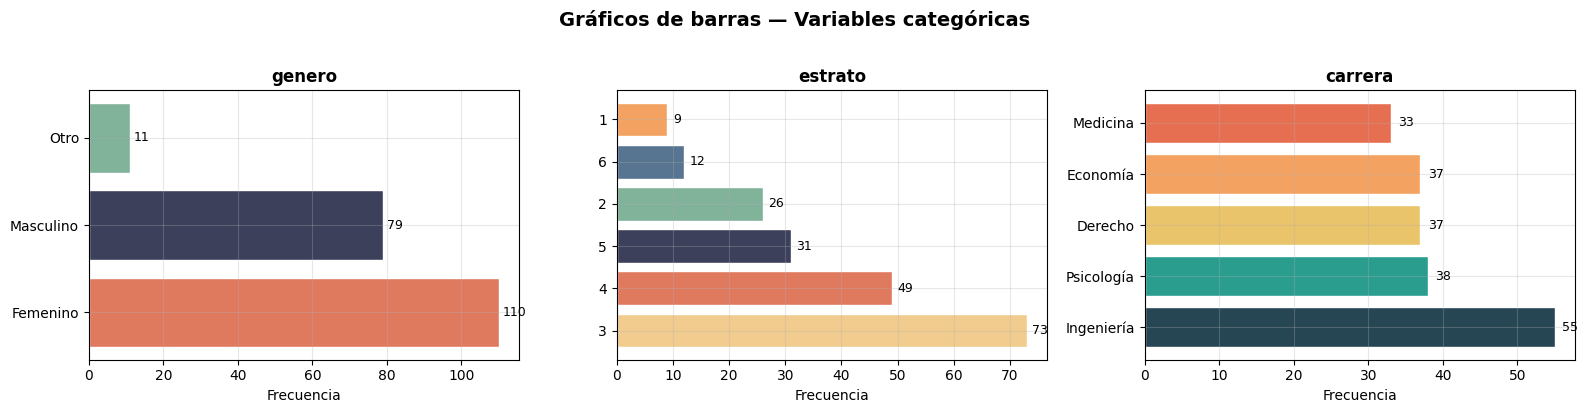

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

paletas = [
    ["#E07A5F", "#3D405B", "#81B29A"],
    ["#F2CC8F", "#E07A5F", "#3D405B", "#81B29A", "#577590", "#F4A261"],
    ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"],
]

for ax, var, colores in zip(axes, vars_categoricas, paletas):
    conteos = df[var].value_counts()
    ax.barh(conteos.index.astype(str), conteos.values, color=colores[:len(conteos)], edgecolor="white")
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    # Añadir etiquetas de valor en cada barra
    for i, v in enumerate(conteos.values):
        ax.text(v + 1, i, str(v), va="center", fontsize=9)

fig.suptitle("Gráficos de barras — Variables categóricas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Gráfico circular (Pie chart)
El gráfico circular muestra la **proporción** de cada categoría respecto al total.

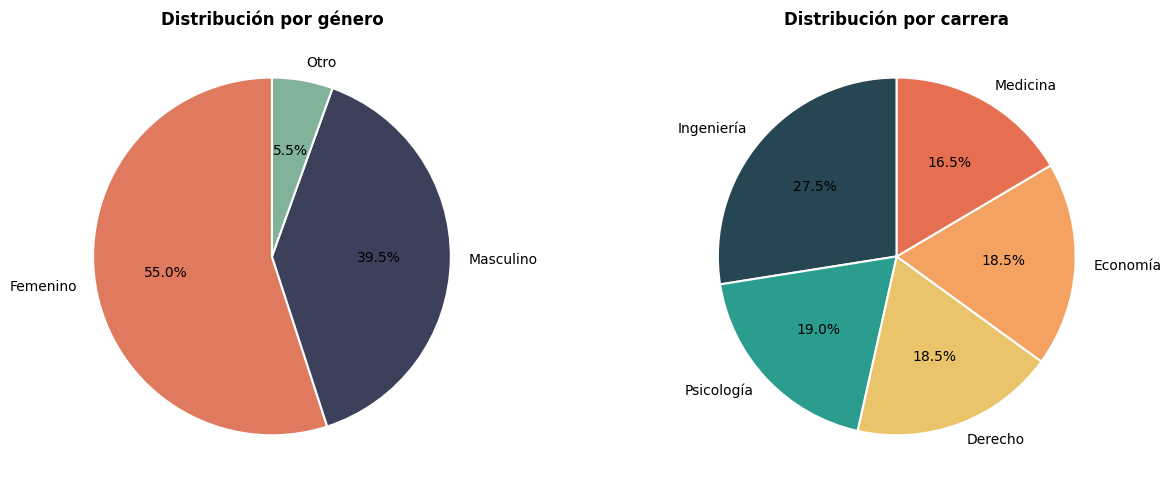

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — Género
conteos_genero = df["genero"].value_counts()
axes[0].pie(
    conteos_genero.values,
    labels=conteos_genero.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#E07A5F", "#3D405B", "#81B29A"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[0].set_title("Distribución por género", fontsize=12, fontweight="bold")

# Pie chart — Carrera
conteos_carrera = df["carrera"].value_counts()
axes[1].pie(
    conteos_carrera.values,
    labels=conteos_carrera.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Distribución por carrera", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

---

## 6. Análisis cruzado: combinando tipos de variables

Una práctica común es **cruzar una variable categórica con una continua o discreta** para comparar distribuciones entre grupos.

In [17]:
# Estadísticas de promedio de notas por carrera
df.groupby("carrera")["promedio_notas"].agg(["mean", "median", "std", "min", "max"]).round(2)

,mean,median,std,min,max
carrera,,,,,
Derecho,3.73,3.62,0.69,2.77,4.97
Economía,3.75,3.84,0.70,2.57,5.00
Ingeniería,3.57,3.39,0.74,2.54,4.92
Medicina,3.72,3.78,0.74,2.63,4.99
Psicología,3.62,3.58,0.69,2.60,4.95


/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_21352/2990617768.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_carrera, labels=carreras, patch_artist=True, vert=True)


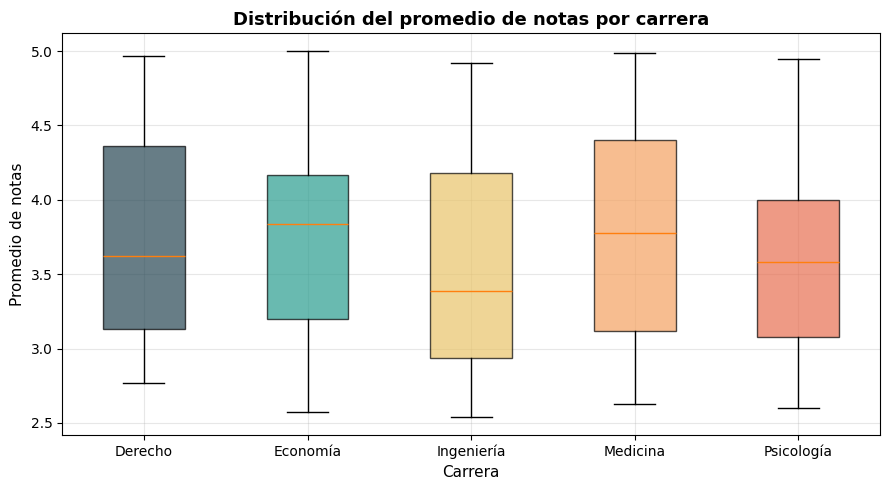

In [18]:
# Boxplot de promedio de notas por carrera
fig, ax = plt.subplots(figsize=(9, 5))

carreras = df["carrera"].cat.categories.tolist()
datos_por_carrera = [df[df["carrera"] == c]["promedio_notas"].values for c in carreras]
colores_carrera = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]

bp = ax.boxplot(datos_por_carrera, labels=carreras, patch_artist=True, vert=True)
for patch, color in zip(bp["boxes"], colores_carrera):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Promedio de notas", fontsize=11)
ax.set_xlabel("Carrera", fontsize=11)
ax.set_title("Distribución del promedio de notas por carrera", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

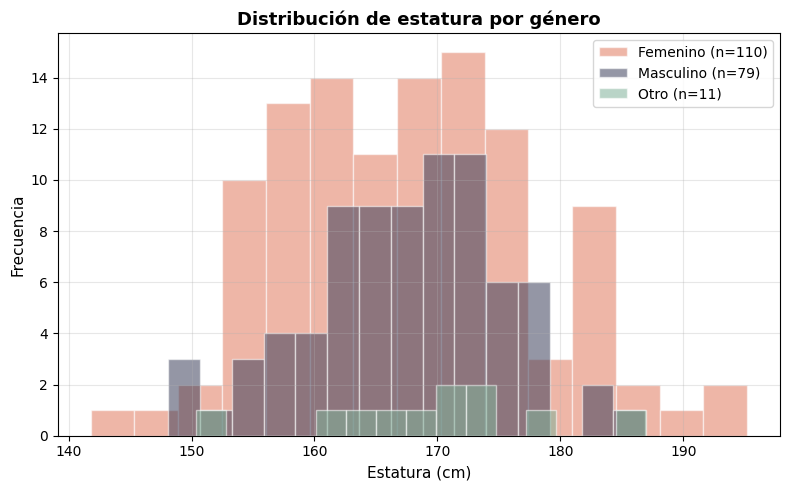

In [19]:
# Histogramas superpuestos: estatura por género
fig, ax = plt.subplots(figsize=(8, 5))

generos = df["genero"].cat.categories.tolist()
colores_gen = ["#E07A5F", "#3D405B", "#81B29A"]

for genero, color in zip(generos, colores_gen):
    datos = df[df["genero"] == genero]["estatura_cm"]
    ax.hist(datos, bins=15, alpha=0.55, label=f"{genero} (n={len(datos)})", color=color, edgecolor="white")

ax.set_xlabel("Estatura (cm)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_title("Distribución de estatura por género", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

---

## 7. Resumen de funciones utilizadas

| Función / Método | Descripción |
|---|---|
| `df.describe()` | Resumen estadístico (media, std, cuartiles, min, max) |
| `df.mean()`, `df.median()` | Media y mediana |
| `df.std()`, `df.var()` | Desviación estándar y varianza |
| `df.skew()`, `df.kurtosis()` | Asimetría y curtosis |
| `df.mode()` | Valor más frecuente (moda) |
| `df.value_counts()` | Tabla de frecuencias absolutas |
| `df.value_counts(normalize=True)` | Tabla de frecuencias relativas |
| `df.groupby().agg()` | Estadísticas agrupadas por categoría |
| `df.corr()` | Matriz de correlación |
| `plt.hist()` | Histograma |
| `plt.boxplot()` | Diagrama de caja |
| `plt.scatter()` | Gráfico de dispersión |
| `plt.bar()` / `plt.barh()` | Gráfico de barras vertical / horizontal |
| `plt.pie()` | Gráfico circular |
| `plt.stem()` | Diagrama de tallo |

### Recomendaciones según tipo de variable

| Tipo de variable | Estadísticas recomendadas | Gráficos recomendados |
|---|---|---|
| **Continua** | Media, mediana, desv. estándar, asimetría, curtosis | Histograma, boxplot, scatter |
| **Discreta** | Media, mediana, moda, tabla de frecuencias | Barras, stem plot, boxplot |
| **Categórica** | Moda, frecuencias absolutas y relativas | Barras, pie chart |